In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [84]:
df = pd.read_csv('Housing_data.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])


In [85]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [86]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

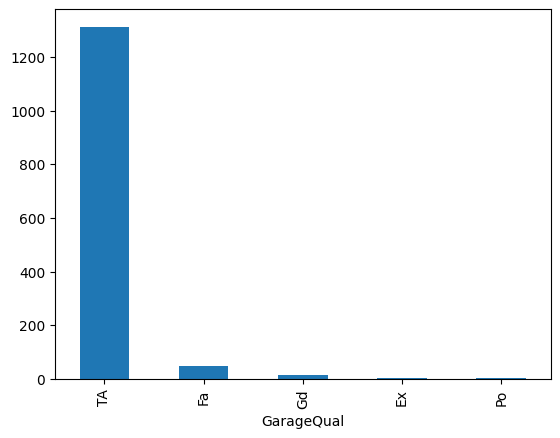

In [87]:
df['GarageQual'].value_counts().plot(kind='bar')

In [88]:
df['GarageQual'].mode()

,GarageQual
0,TA


Text(0.5, 1.0, 'GarageQual')

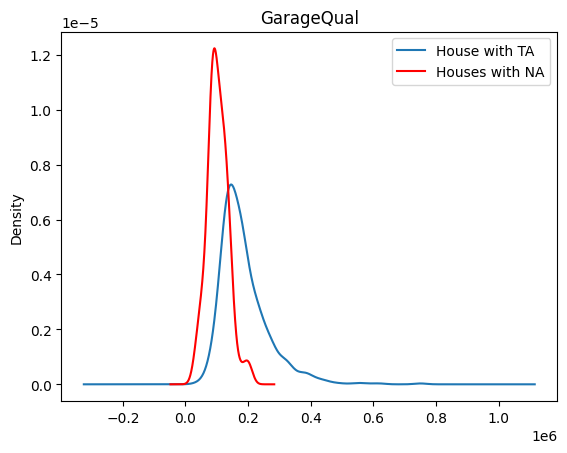

In [89]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['House with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

In [90]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [91]:
df['GarageQual'].fillna('TA', inplace=True)

/tmp/ipykernel_3362/1818999247.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA', inplace=True)


<Axes: xlabel='GarageQual'>

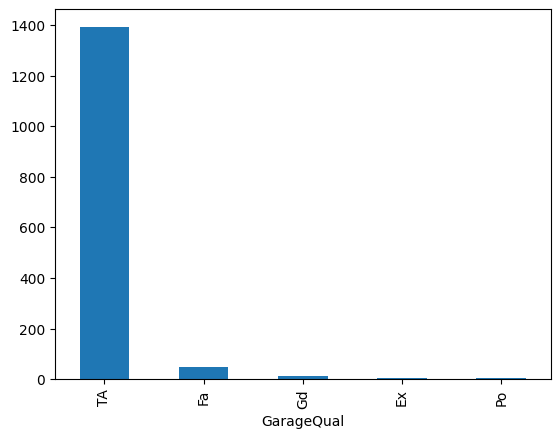

In [92]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

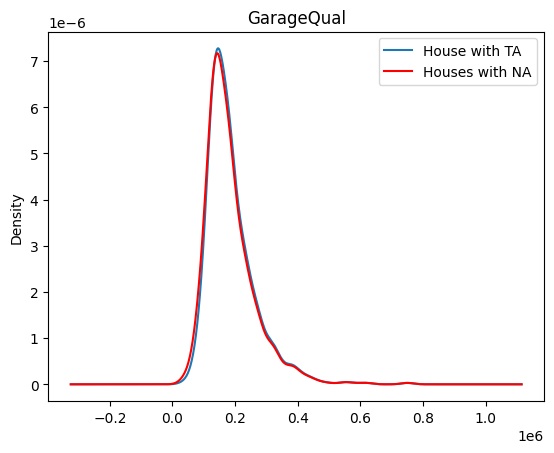

In [93]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)

#distribution of the variable after imputation
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['House with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

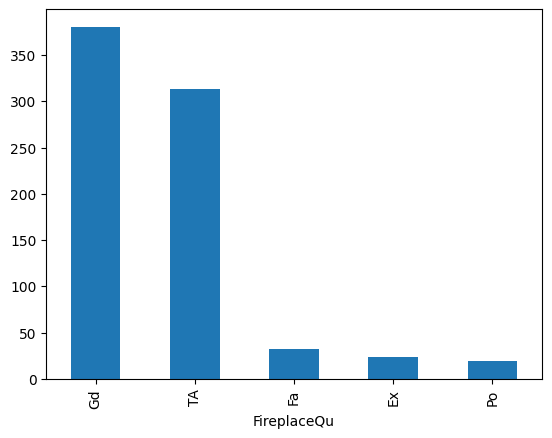

In [94]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [95]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


Text(0.5, 1.0, 'FireplaceQu')

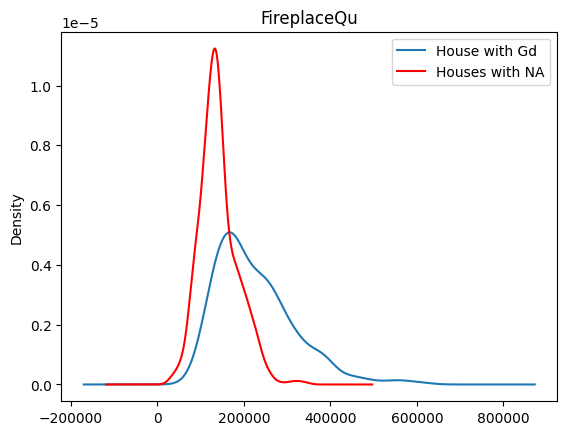

In [96]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['House with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [97]:
temp = df[df['FireplaceQu']=='gd']['SalePrice']

In [98]:
df['FireplaceQu'].fillna('Gd', inplace=True)

/tmp/ipykernel_3362/3912738894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


<Axes: xlabel='FireplaceQu'>

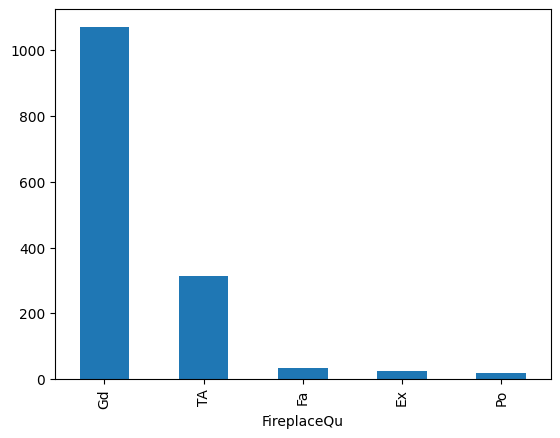

In [99]:
df['FireplaceQu'].value_counts().plot(kind='bar')

/tmp/ipykernel_3362/852190401.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_local['FireplaceQu'].fillna('Gd', inplace=True)


Text(0.5, 1.0, 'FireplaceQu: Original vs Imputed SalePrice Distribution')

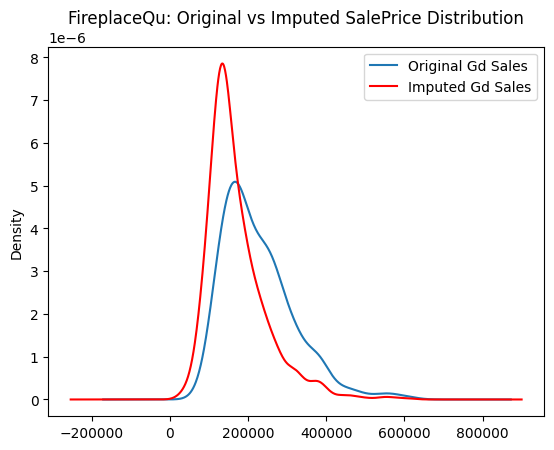

In [100]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data specifically for this plot to ensure we get the original state
df_local = pd.read_csv('Housing_data.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

fig = plt.figure()
ax = fig.add_subplot(111)

# Get the SalePrice distribution for 'Gd' quality from the ORIGINAL (pre-imputation) data
# This will be the 'blue line'
original_gd_sales = df_local[df_local['FireplaceQu']=='Gd']['SalePrice']
original_gd_sales.plot(kind='kde', ax=ax)

# Impute the 'FireplaceQu' column *within this local df*
df_local['FireplaceQu'].fillna('Gd', inplace=True)

# Get the SalePrice distribution for 'Gd' quality from the IMPUTED data
# This will be the 'red line'
imputed_gd_sales = df_local[df_local['FireplaceQu']=='Gd']['SalePrice']
imputed_gd_sales.plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original Gd Sales', 'Imputed Gd Sales']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu: Original vs Imputed SalePrice Distribution')

In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['SalePrice']), df['SalePrice'], test_size=0.2)

In [102]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')

In [103]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [104]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)